# 02 - Treniranje TF-IDF + Logistic Regression modela

Ova sveska prati skriptu `scripts/03_train_tfidf_logreg.py`. Tekst mejla se prvo pretvara u numericke atribute pomocu TF-IDF vektorizacije, a zatim se trenira logisticka regresija.

Model se bira na validacionom skupu. Test skup se ovde ne koristi, jer se cuva za finalnu procenu.

In [9]:
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

ROOT

PosixPath('/Users/markoraskovic/Desktop/ML projekat')

## Ucitavanje trening i validacionog skupa

In [10]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline

TRAIN_PATH = ROOT / "data" / "processed" / "splits" / "train.csv"
VALIDATION_PATH = ROOT / "data" / "processed" / "splits" / "validation.csv"
MODEL_PATH = ROOT / "models" / "tfidf_logreg_pipeline.joblib"
RESULTS_PATH = ROOT / "reports" / "03_tfidf_logreg_results.txt"

train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)

x_train = train_df["message"]
y_train = train_df["label"]
x_validation = validation_df["message"]
y_validation = validation_df["label"]

train_df.head()

,label,message,label_id,char_count,word_count,digit_count,has_currency,has_long_number,normalized_message
0,ham,Subject: english language teaching at waseda u...,0,958,172,25,False,False,subject: english language teaching at waseda u...
1,ham,Subject: call for papers\n\ncall for papers 1s...,0,3013,618,61,False,True,subject: call for papers call for papers 1st a...
2,spam,Subject: free trial membership\n\nthe latest i...,1,526,155,15,False,False,subject: free trial membership the latest in a...
3,spam,Subject: hello\n\nuniversity degree programs i...,1,473,86,13,True,False,subject: hello university degree programs incr...
4,ham,Subject: sum : quantification\n\nabout four we...,0,7264,1440,62,False,True,subject: sum : quantification about four weeks...


## Generisanje kandidata hiperparametara

Menjamo `min_df` i regularizacioni parametar `C`. Ostale vrednosti drzimo fiksnim da pretraga ostane jednostavna.

In [11]:
candidate_parameters = [
    (min_df_param, c_param)
    for min_df_param in [2, 5, 10]
    for c_param in [0.5, 1.0, 2.0, 5.0]
]

print(f"Broj kandidata: {len(candidate_parameters)}")
print(candidate_parameters)

Broj kandidata: 12
[(2, 0.5), (2, 1.0), (2, 2.0), (2, 5.0), (5, 0.5), (5, 1.0), (5, 2.0), (5, 5.0), (10, 0.5), (10, 1.0), (10, 2.0), (10, 5.0)]


## Funkcija koja pravi model na osnovu parametara

Koristimo `Pipeline`, jer on vezuje TF-IDF transformaciju i logisticku regresiju u jedan model.

In [12]:
def napravi_model(min_df_param, c_param):
    return Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=True,
                    strip_accents="unicode",
                    ngram_range=(1, 2),
                    min_df=min_df_param,
                    max_df=0.90,
                    max_features=10000,
                    sublinear_tf=True,
                ),
            ),
            (
                "logistic_regression",
                LogisticRegression(
                    C=c_param,
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=42,
                    solver="liblinear",
                ),
            ),
        ]
    )

## Treniranje kandidata i izbor najboljeg modela

Za svaki par hiperparametara treniramo model na trening skupu i merimo F1 za `spam` i `ham` na validacionom skupu. Primarni fokus je spam klasa.

In [13]:
all_results = []
best_model = None
best_params = None
best_spam_f1 = -1
best_ham_f1 = -1

for min_df_param, c_param in candidate_parameters:
    candidate_model = napravi_model(min_df_param, c_param)
    candidate_model.fit(x_train, y_train)
    predictions = candidate_model.predict(x_validation)

    spam_precision = precision_score(y_validation, predictions, pos_label="spam", zero_division=0)
    spam_recall = recall_score(y_validation, predictions, pos_label="spam", zero_division=0)
    spam_f1 = f1_score(y_validation, predictions, pos_label="spam", zero_division=0)
    ham_f1 = f1_score(y_validation, predictions, pos_label="ham", zero_division=0)

    all_results.append([min_df_param, c_param, spam_precision, spam_recall, spam_f1, ham_f1])

    if spam_f1+ham_f1> best_spam_f1+best_ham_f1:
        best_spam_f1 = spam_f1
        best_ham_f1 = ham_f1
        best_params = (min_df_param, c_param)
        best_model = candidate_model

results_table = pd.DataFrame(
    all_results,
    columns=["min_df", "C", "spam_precision", "spam_recall", "spam_f1", "ham_f1"],
).sort_values("spam_f1", ascending=False, kind="stable")
results_table.head(10)

,min_df,C,spam_precision,spam_recall,spam_f1,ham_f1
0,2,0.5,0.985714,0.985714,0.985714,0.99723
1,2,1.0,0.985714,0.985714,0.985714,0.99723
2,2,2.0,0.985714,0.985714,0.985714,0.99723
3,2,5.0,0.985714,0.985714,0.985714,0.99723
4,5,0.5,0.985714,0.985714,0.985714,0.99723
5,5,1.0,0.985714,0.985714,0.985714,0.99723
6,5,2.0,0.985714,0.985714,0.985714,0.99723
7,5,5.0,0.985714,0.985714,0.985714,0.99723
8,10,0.5,0.985714,0.985714,0.985714,0.99723
9,10,1.0,0.985714,0.985714,0.985714,0.99723


## Graficki prikaz metrika po konfiguraciji

Svaka grupa stubova predstavlja jednu kombinaciju parametara `min_df` i `C`.

Visine stubova dolaze iz kolona `spam_precision`, `spam_recall` i `spam_f1` tabele `results_table`. Te vrednosti su ranije izracunate poredjenjem stvarnih oznaka `y_validation` i predikcija modela `predictions` na validacionom skupu.

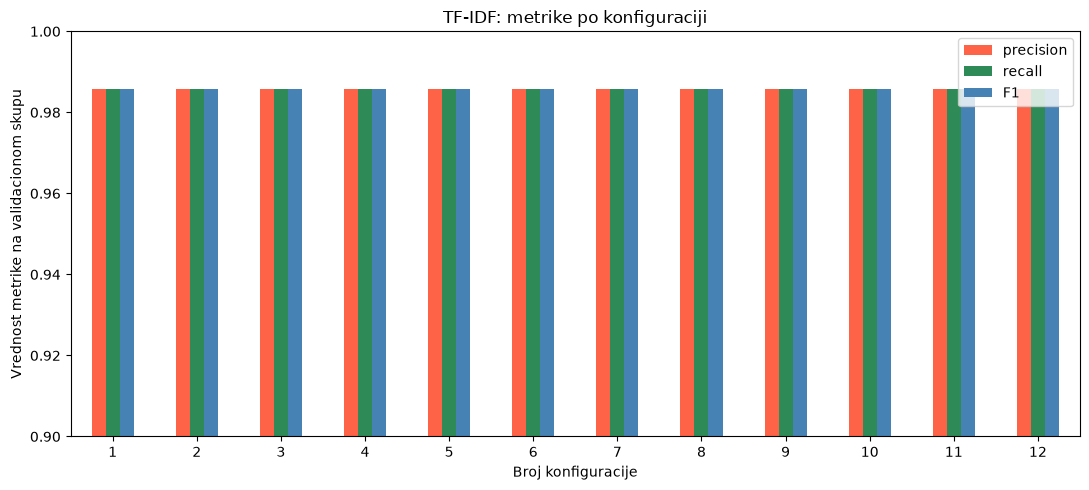

,min_df,C
broj,,
1,2,0.5
2,2,1.0
3,2,2.0
4,2,5.0
5,5,0.5
6,5,1.0
7,5,2.0
8,5,5.0
9,10,0.5


In [14]:
metric_columns = ["spam_precision", "spam_recall", "spam_f1"]
plot_data = results_table.reset_index(drop=True)
plot_data.index = range(1, len(plot_data) + 1)

fig, ax = plt.subplots(figsize=(11, 5))
plot_data[metric_columns].plot(
    kind="bar", ax=ax, ylim=(0.90, 1.00),
    color=["tomato", "seagreen", "steelblue"],
)
ax.set_title("TF-IDF: metrike po konfiguraciji")
ax.set_xlabel("Broj konfiguracije")
ax.set_ylabel("Vrednost metrike na validacionom skupu")
ax.legend(["precision", "recall", "F1"])
ax.set_xticklabels(range(1, len(plot_data) + 1), rotation=0)
fig.tight_layout()
plt.show()

display(plot_data[["min_df", "C"]].rename_axis("broj"))

## Ispis rezultata najboljeg modela na validacionom skupu

In [15]:
validation_predictions = best_model.predict(x_validation)
validation_report = classification_report(y_validation, validation_predictions)
validation_confusion_matrix = confusion_matrix(y_validation, validation_predictions, labels=["ham", "spam"])

print(f"Najbolji parametri: {best_params}")
print(validation_report)

pd.DataFrame(
    validation_confusion_matrix,
    index=["stvarno_ham", "stvarno_spam"],
    columns=["pred_ham", "pred_spam"],
)

Najbolji parametri: (2, 0.5)
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00       361
        spam       0.99      0.99      0.99        70

    accuracy                           1.00       431
   macro avg       0.99      0.99      0.99       431
weighted avg       1.00      1.00      1.00       431



,pred_ham,pred_spam
stvarno_ham,360,1
stvarno_spam,1,69


## Cuvanje modela i rezultata

In [16]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, MODEL_PATH)

with open(RESULTS_PATH, "w", encoding="utf-8") as file:
    file.write("IZBOR HIPERPARAMETARA\n")
    file.write(str(results_table))
    file.write(f"\n\nNajbolji parametri: {best_params}\n\n")
    file.write("VALIDACIONI SKUP\n")
    file.write(validation_report)
    file.write("\n\nMATRICA KONFUZIJE NA VALIDACIONOM SKUPU\n")
    file.write(str(pd.DataFrame(validation_confusion_matrix, index=["stvarno_ham", "stvarno_spam"], columns=["pred_ham", "pred_spam"])))

print(f"Model je sacuvan u: {MODEL_PATH}")
print(f"Rezultati su sacuvani u: {RESULTS_PATH}")

Model je sacuvan u: /Users/markoraskovic/Desktop/ML projekat/models/tfidf_logreg_pipeline.joblib
Rezultati su sacuvani u: /Users/markoraskovic/Desktop/ML projekat/reports/03_tfidf_logreg_results.txt
